In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
import seaborn as sb
from model import cnn
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [3]:
model = cnn()
model.load_state_dict(torch.load('saved_model/best.pth'))

<All keys matched successfully>

In [4]:
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [5]:
test_data = datasets.ImageFolder(root='./dataset/test',transform=test_transform)
val_data = datasets.ImageFolder(root='./dataset/val',transform=val_transform)

In [6]:
test_batch = DataLoader(
    test_data,
    batch_size=16,
    shuffle=False
)

val_batch = DataLoader(
    val_data,
    batch_size=16,
    shuffle=False
)

In [12]:
model.eval()
all_pred = []
all_label = []
miss_image = []
miss_pred = []
miss_label = []

with torch.no_grad():
    for xtest,ytest in test_batch:
        test_pred = model(xtest)
        prob = torch.sigmoid(test_pred)
        val = (prob > 0.5).long()

        all_pred.extend(val.cpu().numpy())
        all_label.extend(ytest.cpu().numpy())

        wrong = (val.squeeze().long() != ytest)
        for i in range(len(wrong)):
            if wrong[i].item():
                miss_image.append(xtest[i])
                miss_label.append(ytest[i].item())
                miss_pred.append(val[i].item())

Accuracy_score = accuracy_score(all_label,all_pred)
cm = confusion_matrix(all_label,all_pred)
cls_report = classification_report(all_label,all_pred)



In [13]:
Accuracy_score

0.92

<Axes: >

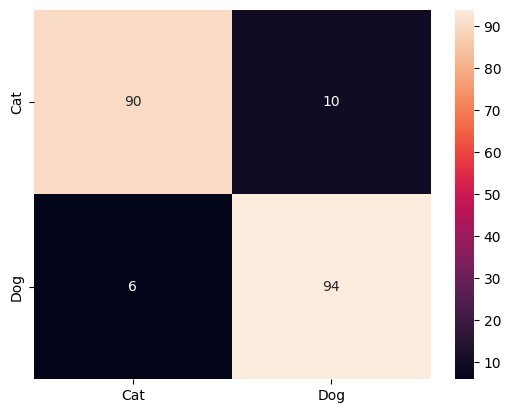

In [16]:
sb.heatmap(
    cm,
    annot=True,
    fmt='d',
    yticklabels=['Cat','Dog'],
    xticklabels=['Cat','Dog']
)


In [17]:
cls_report

'              precision    recall  f1-score   support\n\n           0       0.94      0.90      0.92       100\n           1       0.90      0.94      0.92       100\n\n    accuracy                           0.92       200\n   macro avg       0.92      0.92      0.92       200\nweighted avg       0.92      0.92      0.92       200\n'

In [18]:
model.eval()
all_pred = []
all_label = []


with torch.no_grad():
    for xval,yval in val_batch:
        test_pred = model(xtest)
        prob = torch.sigmoid(test_pred)
        val = (prob > 0.5).long()

        all_pred.extend(val.cpu().numpy())
        all_label.extend(ytest.cpu().numpy())

       
validation_accuracy_score = accuracy_score(all_label,all_pred)




In [19]:
validation_accuracy_score

1.0

miss classified images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.96862745].


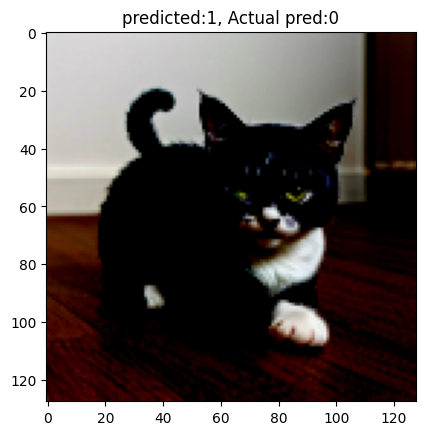

In [22]:
img = miss_image[1]
img = img.permute(1,2,0)
plt.title(f'predicted:{miss_pred[1]}, Actual pred:{miss_label[1]}')
plt.imshow(img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


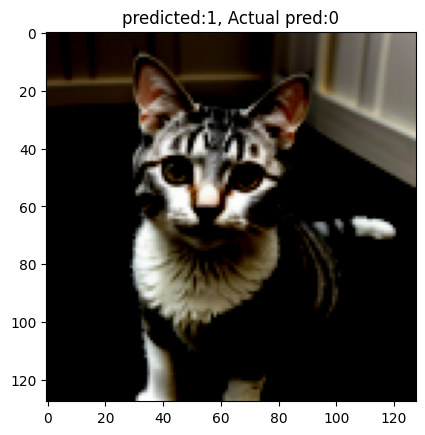

In [23]:
img = miss_image[2]
img = img.permute(1,2,0)
plt.title(f'predicted:{miss_pred[2]}, Actual pred:{miss_label[2]}')
plt.imshow(img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


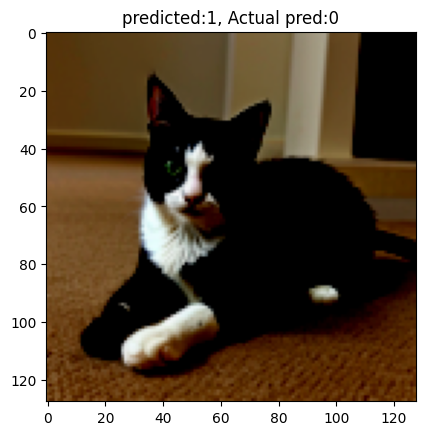

In [24]:
img = miss_image[3]
img = img.permute(1,2,0)
plt.title(f'predicted:{miss_pred[3]}, Actual pred:{miss_label[3]}')
plt.imshow(img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.90588236].


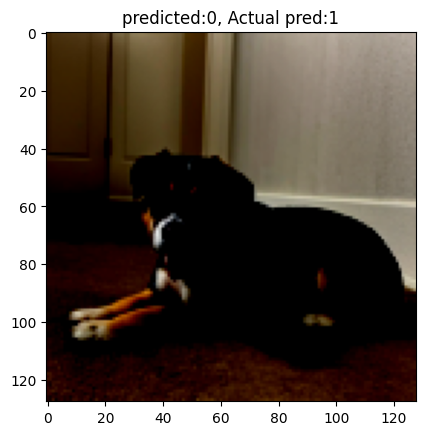

In [25]:
img = miss_image[11]
img = img.permute(1,2,0)
plt.title(f'predicted:{miss_pred[11]}, Actual pred:{miss_label[11]}')
plt.imshow(img)